<table align="center">
  <td align="center"><a target="_blank" href="http://introtodeeplearning.com">
        <img src="https://i.ibb.co/Jr88sn2/mit.png" style="padding-bottom:5px;" />
      Visit MIT Deep Learning</a></td>
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/MITDeepLearning/introtodeeplearning/blob/master/lab1/TF_Part1_Intro.ipynb">
        <img src="https://i.ibb.co/2P3SLwK/colab.png"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
  <td align="center"><a target="_blank" href="https://github.com/MITDeepLearning/introtodeeplearning/blob/master/lab1/TF_Part1_Intro.ipynb">
        <img src="https://i.ibb.co/xfJbPmL/github.png"  height="70px" style="padding-bottom:5px;"  />View Source on GitHub</a></td>
</table>

# Copyright Information


In [1]:
# Copyright 2026 MIT Introduction to Deep Learning. All Rights Reserved.
#
# Licensed under the MIT License. You may not use this file except in compliance
# with the License. Use and/or modification of this code outside of MIT Introduction
# to Deep Learning must reference:
#
# © MIT Introduction to Deep Learning
# http://introtodeeplearning.com
#

# Lab 1: Intro to TensorFlow/Keras and Music Generation with RNNs

In this lab you'll get exposure to TensorFlow and Keras, and learn how they can
be used for deep learning. Go through the code and run each cell. Along the
way you'll encounter several **_TODO_** blocks — follow the instructions to fill
them out before running those cells and continuing.

# Part 1: Intro to TensorFlow / Keras

## 0.1 Install TensorFlow

[TensorFlow](https://www.tensorflow.org/) is Google's open-source machine
learning framework. [Keras](https://keras.io/) ships as the high-level API
bundled inside TensorFlow (`tf.keras`). For this lab we use TensorFlow 2.x
with the eager execution default.


### First-Principles Roadmap

![Deep learning first-principles roadmap from tensors through automatic differentiation, training, scaling, and pretrained music generation](images/deep-learning-first-principles-roadmap.png)

This notebook builds one learning cycle from first principles: data becomes tensor computations, a model produces predictions, a loss produces gradients, and an optimizer updates parameters. The later production and music-generation sections reuse the same core ideas at a different scale.


## What You'll Learn: TensorFlow & Keras from First Principles

This notebook builds your intuition for how **TensorFlow** represents computation as graphs, defines models with **Keras layers**, and trains them with **automatic differentiation** — using a **single running example throughout**.

Every concept is demonstrated on the same problem:

> **Classifying 2D points: inside a circle (class 1) vs. outside (class 0)**  
> 200 points, 2 features (x₀, x₁) → binary label. Small enough to visualise, real enough to matter.

### Roadmap

| Step | Concept                 | Key Idea                                                                    |
| ---- | ----------------------- | --------------------------------------------------------------------------- |
| 1    | Vocabulary & Toy Data   | Our running example: classifying 2D points (circle vs square)               |
| 2    | Tensors & Shapes        | Multi-dimensional arrays (`tf.Tensor`) as TensorFlow's substrate            |
| 3    | Computation Graphs      | Operations (add, matmul) form a dependency DAG; TF tracks it implicitly     |
| 4    | Keras Layers            | Dense, Activation, custom `Layer` subclasses as composable building blocks  |
| 5    | The Forward Pass        | `model(inputs)` returns predictions; weights are random until trained       |
| 6    | Autodiff & Backprop     | `GradientTape` computes $\partial L/\partial W$ — no hand-coded derivatives |
| 7    | Training Loop           | Gradient descent: `tape.gradient` → `optimizer.apply_gradients` → repeat    |
| 8    | Toy → Production Bridge | Same mechanisms (GradientTape, Dense, optimizer), just far more parameters  |
| 9    | Pretrained Music Model  | HuggingFace Transformers: autodiff deployed at billion-parameter scale      |

### Topic Scope: What This Notebook Covers, Explains, and Defers

"TensorFlow/Keras fundamentals" is a bigger space than any one notebook builds from scratch. So
nothing below is an accidental gap — here's the shape of the whole space up front. The closing
section revisits this same breakdown in full once you've seen everything it refers to.

| Area                                                                           | In this notebook                                                          |
| ------------------------------------------------------------------------------ | ------------------------------------------------------------------------- |
| Tensors, shapes, computation graphs                                            | Built (Steps 2–3)                                                         |
| Eager execution vs. `@tf.function` graph mode                                  | Eager built; `@tf.function` shown briefly (Step 3)                        |
| Keras model-building APIs (Sequential / Functional / Subclassing)              | Sequential + Subclassing built; Functional API shown briefly (Step 4)     |
| `GradientTape` autodiff, incl. `tape.watch()` on non-`Variable`s               | Built and verified (Step 6)                                               |
| Manual training loop vs. `model.compile()` / `model.fit()`                     | Manual loop built; high-level API shown briefly (Step 7)                  |
| Mini-batching, `tf.data.Dataset`, validation splits, regularization, callbacks | Not covered — trained full-batch with no held-out set; see closing ledger |
| RNNs / LSTM / GRU / sequence modeling                                          | Not covered — explicitly deferred to Lab 2 (Part 2 explains why)          |


## Table of Contents

1. [0.1 Install TensorFlow](#01-install-tensorflow)
2. [What You'll Learn: TensorFlow & Keras from First Principles](#what-youll-learn-tensorflow-keras-from-first-principles)
   - [Topic Scope: What This Notebook Covers, Explains, and Defers](#topic-scope-what-this-notebook-covers-explains-and-defers)
3. [1.0 Our Running Example: Circle vs. Square (2D Binary Classifier)](#10-our-running-example-circle-vs-square-2d-binary-classifier)
4. [1.1 What is TensorFlow?](#11-what-is-tensorflow)
5. [1.2 Computations on Tensors](#12-computations-on-tensors)
   - [Predict First: Eager vs. Graph Execution](#predict-first-eager-vs-graph-execution)
   - [Aside: `@tf.function` — TF2's Opt-In Graph Mode](#aside-tffunction-tf2s-opt-in-graph-mode)
6. [1.3 Neural networks in Keras](#13-neural-networks-in-keras)
   - [Predict First: Can Sequential Express a Skip Connection?](#predict-first-can-sequential-express-a-skip-connection)
   - [Aside: The Functional API](#aside-the-functional-api)
7. [1.4 Automatic Differentiation in TensorFlow](#14-automatic-differentiation-in-tensorflow)
   - [Aside: `tape.watch()` for Non-`Variable` Tensors](#aside-tapewatch-for-non-variable-tensors)
   - [Predict First: Does the Hidden-Layer Nonlinearity Actually Matter?](#predict-first-does-the-hidden-layer-nonlinearity-actually-matter)
   - [Aside: The High Road — `model.compile()` + `model.fit()`](#aside-the-high-road-modelcompile-modelfit)
   - [Your turn — how wide does the hidden layer need to be?](#your-turn-how-wide-does-the-hidden-layer-need-to-be)
8. [1.5 Toy → Production Bridge: Same Loop, Bigger Models](#15-toy-production-bridge-same-loop-bigger-models)
9. [Part 2: Pretrained Transformers at Scale](#part-2-pretrained-transformers-at-scale)
   - [Option A — `facebook/musicgen-small`](#option-a-facebookmusicgen-small-text-prompt-audio)
   - [Option B — `sander-wood/tunesformer`](#option-b-sander-woodtunesformer-abc-seed-abc-notation)
10. [What This Notebook Covered (and What It Didn't)](#what-this-notebook-covered-and-what-it-didnt)
11. [Summary — What You Built](#summary-what-you-built)

> Links jump to the matching heading below. If a link doesn't scroll correctly in your Jupyter
> viewer, use `Ctrl+F` / the notebook outline panel with the section title instead.


In [ ]:
# ── Imports & Environment Setup ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

# ── Set Seeds for Reproducibility ───────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)
print("Seeds set: TF=42, NumPy=42 (outputs will be deterministic)")

print("TensorFlow version:", tf.__version__)

Seeds set: TF=42, NumPy=42 (outputs will be deterministic)
TensorFlow version: 2.21.0


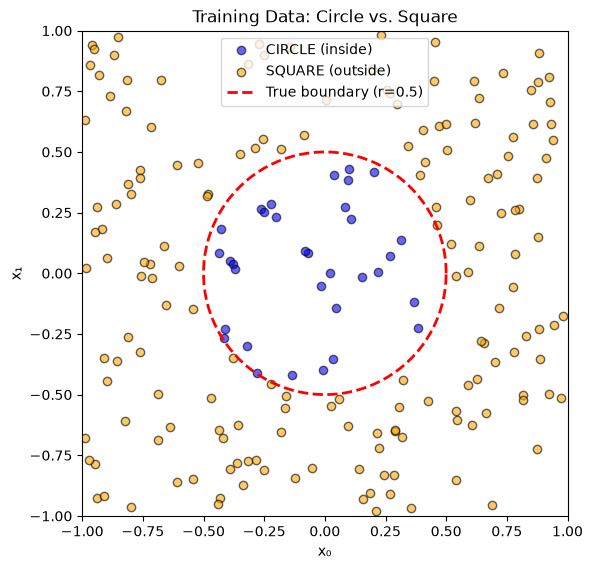

Training set: 200 points, 33 CIRCLE, 167 SQUARE


In [3]:
# ── Generate Training Data: 2D Points ───────────────────────────────────────
n_samples = 200
X_train = np.random.uniform(-1, 1, (n_samples, 2)).astype(np.float32)

# Label: CIRCLE (1) if inside radius 0.5, else SQUARE (0)
distances = np.sqrt(X_train[:, 0] ** 2 + X_train[:, 1] ** 2)
y_train = (distances < 0.5).astype(np.float32)

# ── Visualize the Dataset ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))

# Plot points
circle_mask = y_train == 1
ax.scatter(
    X_train[circle_mask, 0],
    X_train[circle_mask, 1],
    c="blue",
    label="CIRCLE (inside)",
    alpha=0.6,
    edgecolors="k",
)
ax.scatter(
    X_train[~circle_mask, 0],
    X_train[~circle_mask, 1],
    c="orange",
    label="SQUARE (outside)",
    alpha=0.6,
    edgecolors="k",
)

# Overlay the true boundary (radius 0.5)
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(
    0.5 * np.cos(theta),
    0.5 * np.sin(theta),
    "r--",
    linewidth=2,
    label="True boundary (r=0.5)",
)

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect("equal")
ax.legend()
ax.set_title("Training Data: Circle vs. Square")
ax.set_xlabel("x₀")
ax.set_ylabel("x₁")
plt.tight_layout()
plt.show()

print(
    f"Training set: {n_samples} points, {y_train.sum():.0f} CIRCLE, {(1-y_train).sum():.0f} SQUARE"
)

### Code Walkthrough: Generating the Circle-vs-Square Training Set

**What just ran — 3 key patterns:**

---

**`np.random.uniform(-1, 1, (n_samples, 2))` — uniform 2D sampling**
Samples `n_samples = 200` points whose `(x₀, x₁)` coordinates both fall in `[-1, 1]`. This becomes the feature matrix `X_train` with shape `(200, 2)` — two features per example, no preprocessing needed. The square `[-1,1]² ` domain ensures the circular boundary (radius 0.5) is comfortably surrounded by SQUARE-class points.

---

**`(distances < 0.5).astype(np.float32)` — the ground-truth label**
`np.sqrt(X[:,0]² + X[:,1]²)` computes Euclidean distance from the origin for every point. Thresholding at 0.5 assigns binary label `1.0` (CIRCLE, inside) or `0.0` (SQUARE, outside). Because the circle occupies $\pi r^2 / 4 \approx 20\%$ of the square domain, roughly 40 of 200 points are CIRCLE — a mild class imbalance.

---

**`ax.plot(0.5*cos(θ), 0.5*sin(θ), "r--")` — parametric circle overlay**
The true decision boundary (a circle of radius 0.5) is drawn as a dashed red line using the parametric equations $x = r\cos\theta$, $y = r\sin\theta$. This ground-truth line is the reference for evaluating how closely the model's _learned_ boundary (shown in later cells) matches it.


## 1.0 Our Running Example: Circle vs. Square (2D Binary Classifier)

Throughout Part 1 we'll work with a simple toy problem: **classifying 2D points** as CIRCLE (inside a radius-0.5 circle centered at the origin) or SQUARE (outside that circle). This gives us:

- **Concrete data** to visualize at every step
- **A clear decision boundary** to see what the model learns
- **The same structure** as real classification tasks, just in 2D instead of 784D (MNIST) or 150,528D (ImageNet)

When you understand how TensorFlow trains this toy classifier, you understand how it trains ResNet-50 on ImageNet — same loss function, same GradientTape, same optimizer.apply_gradients.


## 1.1 What is TensorFlow?

TensorFlow is a machine learning library. At its core it provides an interface
for creating and manipulating **tensors** — multi-dimensional arrays of base
datatypes such as integers or floats. `tf.Tensor` objects are immutable
constant values (use `tf.Variable` for mutable state).

The [`shape`](https://www.tensorflow.org/api_docs/python/tf/TensorShape) of a
tensor defines its number of dimensions and the size of each dimension.
`ndim` (or `rank`) gives the number of dimensions.

Let's create some tensors and inspect their properties:


In [4]:
integer = tf.constant(1234)
decimal = tf.constant(3.14159265359)

print(f"`integer` is a {integer.ndim}-d Tensor: {integer}")
print(f"`decimal` is a {decimal.ndim}-d Tensor: {decimal}")

`integer` is a 0-d Tensor: 1234
`decimal` is a 0-d Tensor: 3.1415927410125732


Vectors and lists can be used to create 1-d tensors:


In [5]:
fibonacci = tf.constant([1, 1, 2, 3, 5, 8])
count_to_100 = tf.constant(list(range(100)))

print(f"`fibonacci` is a {fibonacci.ndim}-d Tensor with shape: {fibonacci.shape}")
print(
    f"`count_to_100` is a {count_to_100.ndim}-d Tensor with shape: {count_to_100.shape}"
)

`fibonacci` is a 1-d Tensor with shape: (6,)
`count_to_100` is a 1-d Tensor with shape: (100,)


Next, let's create 2-d (matrices) and higher-rank tensors. In image processing
we use 4-d Tensors with dimensions `(batch, height, width, channels)` — note
that TensorFlow defaults to **NHWC** order (channels last), the opposite of
PyTorch's NCHW.


In [6]:
# ── Defining Higher-Order Tensors ───────────────────────────────────────────

"""TODO: Define a 2-d Tensor from 5 sample points of our training data"""

sample_points = X_train[:5]  # shape (5, 2)
matrix = tf.constant(sample_points)

assert isinstance(matrix, tf.Tensor), "matrix must be a tf.Tensor"
assert matrix.ndim == 2
print(
    f"matrix (5 training points) is a {matrix.ndim}-d Tensor with shape: {matrix.shape}"
)

"""TODO: Convert y_train labels into a 1-d Tensor"""
labels_tensor = tf.constant(y_train)

assert isinstance(labels_tensor, tf.Tensor), "labels_tensor must be a tf.Tensor"
assert labels_tensor.ndim == 1
print(
    f"labels_tensor is a {labels_tensor.ndim}-d Tensor with shape: {labels_tensor.shape}"
)

# ── Optional: 4-d image batch (NHWC format) ──────────────────────────────────
# While our running example is 2D points, image models use 4-d Tensors:
# (batch, height, width, channels) — TensorFlow's NHWC order (channels last).
images = tf.zeros((10, 256, 256, 3))
assert images.shape == (10, 256, 256, 3), "images is incorrect shape (expected NHWC)"
print(f"[Side note] images is a {images.ndim}-d Tensor with shape: {images.shape}")

matrix (5 training points) is a 2-d Tensor with shape: (5, 2)
labels_tensor is a 1-d Tensor with shape: (200,)
[Side note] images is a 4-d Tensor with shape: (10, 256, 256, 3)


As you have seen, the `shape` of a tensor provides the number of elements in
each dimension. You can also use slicing to access sub-tensors within a
higher-rank tensor:


In [7]:
row_vector = matrix[1]
column_vector = matrix[:, 1]
scalar = matrix[0, 1]

print(f"`row_vector`: {row_vector}")
print(f"`column_vector`: {column_vector}")
print(f"`scalar`: {scalar}")

`row_vector`: [0.4639879  0.19731697]
`column_vector`: [ 0.90142864  0.19731697 -0.68801093  0.7323523   0.41614515]
`scalar`: 0.9014286398887634


## 1.2 Computations on Tensors

A convenient way to think about and visualise computations in TensorFlow is in
terms of a **computation graph**. We can define the graph in terms of tensors
(data) and the operations that act on them. Let's look at a simple example:

![add graph](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/add-graph.png)


In [8]:
# Create the nodes in the graph and initialise values
a = tf.constant(15)
b = tf.constant(61)

# Add them!
c1 = tf.add(a, b)
c2 = a + b  # TF overrides + to act on tensors

print(f"c1: {c1}")
print(f"c2: {c2}")

c1: 76
c2: 76


Notice how the output is a tensor with value 76.

Now let's consider a slightly more complicated example:

![computation graph](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/computation-graph.png)

We take two inputs `a, b` and compute an output `e`. Each node represents an
operation. Let's define a simple function in TensorFlow to construct this
computation:


In [9]:
# ── Defining Tensor Computations ────────────────────────────────────────────


def func(a, b):
    """TODO: Define the operations for c, d, e."""
    c = tf.add(a, b)
    d = tf.subtract(b, 1)
    e = tf.multiply(c, d)
    return e

Now we can call the function to execute the computation graph:


In [10]:
# ── Execute Computation Graph ───────────────────────────────────────────────
a, b = 1.5, 2.5
e_out = func(a, b)
print(f"e_out: {e_out}")

# **Answer**: In TF 2.x, this executes eagerly — you get the value 6.0 immediately.
# TF 1.x required session.run(); TF 2.x runs like NumPy by default.

e_out: 6.0


In [11]:
# ── PROVING the computation graph ────────────────────────────────────────────
# Each operation returns a tensor. Let's trace the dependency chain by hand.
a_v, b_v = 1.5, 2.5
print("Step-by-step computation:")
c_v = a_v + b_v
print(f"  c = a + b = {a_v} + {b_v} = {c_v}")
d_v = b_v - 1
print(f"  d = b - 1 = {b_v} - 1  = {d_v}")
e_v = c_v * d_v
print(f"  e = c * d = {c_v} * {d_v} = {e_v}")
print(f"\nfunc({a_v}, {b_v}) returned {e_v} — matches the hand trace.")
print("\nDependency graph:")
print("  a (input) ─┬─► c = a+b ─┐")
print("  b (input) ─┴─► d = b-1 ─┴─► e = c*d  (output)")
print("\nTensorFlow tracks this DAG implicitly so GradientTape can walk it backwards.")

Step-by-step computation:
  c = a + b = 1.5 + 2.5 = 4.0
  d = b - 1 = 2.5 - 1  = 1.5
  e = c * d = 4.0 * 1.5 = 6.0

func(1.5, 2.5) returned 6.0 — matches the hand trace.

Dependency graph:
  a (input) ─┬─► c = a+b ─┐
  b (input) ─┴─► d = b-1 ─┴─► e = c*d  (output)

TensorFlow tracks this DAG implicitly so GradientTape can walk it backwards.


### Proving the Computation Graph: Step-by-Step Trace

Even though execution is eager, TensorFlow still **tracks the dependency DAG** (directed acyclic graph) behind the scenes — this is what `GradientTape` uses for automatic differentiation. Let's trace the computation manually:

| Operation   | Depends On     | Value |
| ----------- | -------------- | ----- |
| `c = a + b` | `a=1.5, b=2.5` | `4.0` |
| `d = b - 1` | `b=2.5`        | `1.5` |
| `e = c * d` | `c=4.0, d=1.5` | `6.0` |

**Key insight**: The final output `e` depends on both `a` and `b` through different paths in the graph. TensorFlow tracks this dependency structure so that when we later ask "how does `e` change if I nudge `a`?", `GradientTape` can automatically compute $\partial e/\partial a$ by walking the graph backward — no hand-coded derivatives.


### Computation Graph and Automatic Differentiation

![Forward computation graph and reverse-mode automatic differentiation from scalar loss back to trainable parameters](images/computation-graph-and-autodiff.png)

The forward pass computes intermediate values and a scalar loss. Reverse-mode autodiff then applies the chain rule from that loss back through the graph. In TensorFlow, `GradientTape` records the forward operations needed to compute gradients for the watched trainable variables.


### Predict First: Eager vs. Graph Execution

Before running the next cell, **predict**: when we write `c = a + b` in TensorFlow 2.x, does it:

**(A)** Execute immediately and return the numeric value 76 (eager execution)?  
**(B)** Return a lazy graph placeholder like `<tf.Tensor 'add:0' shape=() dtype=int32>` (graph mode, as in TF 1.x)?

Think about it, then run the cell to see the answer.


In [ ]:
# Prediction check: TF 2.x executes EAGERLY by default
a = tf.constant(15)
b = tf.constant(61)
c = a + b
print(f"c = {c.numpy()}   ← this is a concrete value, not a graph node")
print("✓ Answer: (B) TF 2.x is eager by default. c immediately holds 76.")
print("  (TF 1.x would have printed 'Tensor(Add:0, shape=(), dtype=int32)' instead)")

c = 76   ← this is a concrete value, not a graph node
✓ Answer: (B) TF 2.x is eager by default. c immediately holds 76.
  (TF 1.x would have printed 'Tensor(Add:0, shape=(), dtype=int32)' instead)


### Aside: `@tf.function` — TF2's Opt-In Graph Mode

The predict-first check above showed TF2 runs eagerly by default. But TF2 didn't remove graphs, it
made them opt-in: wrapping a function in `@tf.function` traces it into a graph the first time it's
called (using AutoGraph), then reuses that compiled graph on every subsequent call. Let's compile
the same `func(a, b)` from a few cells up and confirm it returns an identical result.


In [ ]:
# ── @tf.function: opt-in graph-mode compilation ─────────────────────────────
@tf.function
def func_graph(a, b):
    c = tf.add(a, b)
    d = tf.subtract(b, 1)
    e = tf.multiply(c, d)
    return e


# Same inputs as the eager `func(a, b)` cell above
result_eager = func(1.5, 2.5)
result_graph = func_graph(tf.constant(1.5), tf.constant(2.5))

print(f"Eager  func(1.5, 2.5)       = {result_eager}")
print(f"Graph  func_graph(1.5, 2.5) = {result_graph.numpy()}")
assert np.isclose(result_graph.numpy(), result_eager)
print(
    "\n✓ Same result — @tf.function just traces the same operations into a reusable graph."
)
print(
    "  First call traces (slower); every call after reuses the compiled graph (faster)."
)
print(
    "  This is why performance-critical training loops are often wrapped in a @tf.function 'train_step'."
)

### Reflection: From Computation to Learning

We've built and traced a computation graph (`a + b → c`, `b - 1 → d`, `c * d → e`), but we never asked: **"Which input matters most for the output?"**

- Does `e` change more when we nudge `a` or when we nudge `b`?
- In other words, what is $\partial e/\partial a$ vs. $\partial e/\partial b$?

This question — **"how sensitive is the output to each input?"** — is the core of training neural networks. If we can compute $\partial \text{Loss}/\partial W$ for every weight $W$, we can use gradient descent to minimize the loss.

**The problem**: for a 25-million-parameter ResNet, hand-coding $\partial \text{Loss}/\partial W$ for every weight is impossible. That's where **automatic differentiation** comes in — TensorFlow computes all those derivatives for us by walking the computation graph backward. Let's see how.


## 1.3 Neural networks in Keras

We define neural networks in Keras. The base building block is
[`tf.keras.layers.Layer`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer),
which is the Keras equivalent of PyTorch's `nn.Module`.

A single dense layer performs a **weighted vote followed by a squashing decision**: it multiplies each input feature by a learned weight (how much does this feature matter?), adds a bias (what is the default inclination?), then squashes the result through a sigmoid to get a probability between 0 and 1. In compact notation: $y = \sigma(Wx + b)$.

The **sigmoid** is what makes this a "soft" threshold rather than a hard step function — it is differentiable everywhere, which is exactly what `GradientTape` needs to compute `∂loss/∂W` during training. Without a differentiable nonlinearity, stacking layers collapses to a single linear transformation, incapable of learning curved decision boundaries like circle-vs-square.

![dense layer](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/computation-graph-2.png)

We subclass `tf.keras.layers.Layer` and override **`call()`** (the Keras
equivalent of PyTorch's `forward()`). Weights are created with
`self.add_weight()` inside `build()` or `__init__`.


In [ ]:
# ── Defining a Dense Layer ──────────────────────────────────────────────────


class OurDenseLayer(tf.keras.layers.Layer):
    def __init__(self, num_outputs):
        super(OurDenseLayer, self).__init__()
        self.num_outputs = num_outputs

    def build(self, input_shape):
        # Initialise W and b as trainable weights.
        # Note: weight initialisation is random by default.
        self.W = self.add_weight(
            shape=(int(input_shape[-1]), self.num_outputs),
            initializer="random_normal",
            trainable=True,
        )
        self.bias = self.add_weight(
            shape=(self.num_outputs,), initializer="random_normal", trainable=True
        )

    def call(self, x):
        """TODO: define the operation for z (hint: use tf.matmul)."""
        z = tf.matmul(x, self.W) + self.bias

        """TODO: define the operation for y (hint: use tf.sigmoid)."""
        y = tf.sigmoid(z)
        return y


print(
    "OurDenseLayer defined — add_weight() registers W and bias as trainable Keras variables."
)
print(
    "GradientTape will track gradients through them automatically when call() is invoked."
)

Now, let's test the output of our layer.


In [14]:
# Define a layer and test the output!
num_inputs = 2
num_outputs = 3
layer = OurDenseLayer(num_outputs)
x_input = tf.constant([[1, 2.0]])
y = layer(x_input)

print(f"input shape:  {x_input.shape}")
print(f"output shape: {y.shape}")
print(f"output result: {y}")

input shape:  (1, 2)
output shape: (1, 3)
output result: [[0.48678297 0.48455015 0.5019185 ]]


Conveniently, Keras provides built-in layers such as
[`tf.keras.layers.Dense`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)
(the equivalent of PyTorch's `nn.Linear`) and activation layers.

Now, instead of a single custom layer, we'll use the
[`tf.keras.Sequential`](https://www.tensorflow.org/api_docs/python/tf/keras/Sequential)
API with a single `Dense` layer to define our network.


In [15]:
# ── Defining a Neural Network Using the Keras Sequential API ────────────────

# Let's build a small binary classifier for our 2D circle-vs-square problem:
#   - Input: 2D point (x₀, x₁)
#   - Hidden: Dense(4, relu)
#   - Output: Dense(1, sigmoid) → probability of CIRCLE

model = tf.keras.Sequential(
    [
        layers.Dense(4, activation="relu", input_shape=(2,)),
        layers.Dense(1, activation="sigmoid"),
    ]
)

print("Model summary:")
model.summary()

Model summary:

C:\r\ai-portfolio\learning\genai\01-rnns\MIT\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

We've defined our model using the Sequential API. Now let's test it:


In [16]:
# ── Test the Untrained Model ────────────────────────────────────────────────
# Predict on a few training points (untrained model → ~50% predictions)

x_test_sample = tf.constant(X_train[:5])
model_output = model(x_test_sample)

print(f"input shape:  {x_test_sample.shape}")
print(f"output shape: {model_output.shape}")
print("\nUntrained predictions (should be ~0.5 random):")
for i, (point, pred) in enumerate(zip(x_test_sample.numpy(), model_output.numpy())):
    true_label = y_train[i]
    print(
        f"  Point {i}: {point} → pred={pred[0]:.3f}, true={int(true_label)} ({'CIRCLE' if true_label else 'SQUARE'})"
    )

input shape:  (5, 2)


output shape: (5, 1)

Untrained predictions (should be ~0.5 random):
  Point 0: [-0.25091976  0.90142864] → pred=0.576, true=0 (SQUARE)
  Point 1: [0.4639879  0.19731697] → pred=0.525, true=0 (SQUARE)
  Point 2: [-0.6879627  -0.68801093] → pred=0.343, true=0 (SQUARE)
  Point 3: [-0.88383275  0.7323523 ] → pred=0.455, true=0 (SQUARE)
  Point 4: [0.20223002 0.41614515] → pred=0.537, true=1 (CIRCLE)


### Predict First: Can Sequential Express a Skip Connection?

The `Sequential` API is convenient for stacking layers in a straight line: input → layer1 → layer2 → output.

Before continuing, **predict**: can `Sequential` express a **residual/skip connection** where the output is `layer2(layer1(x)) + x` (i.e., the input bypasses layer1 and gets added to the output)?

**(A)** Yes, with a special `layers.Add()` layer  
**(B)** No — Sequential only supports linear chains; skip connections require Model subclassing

Think about it, then read on.


**Answer**: **(B) — Sequential cannot express skip connections.** To add the input to a middle-layer output, you need to **subclass `tf.keras.Model`** and manually wire the connections in `call()`. Let's see how.


In [ ]:
# ── Defining a Model Using Subclassing (with Skip Connection) ───────────────


class ResidualClassifier(tf.keras.Model):
    """
    A binary classifier with a residual/skip connection:
      output = Dense(1, sigmoid)(Dense(4, relu)(padded_input) + padded_input)

    Sequential cannot express this because the input bypasses the hidden layer
    and gets added back before the final Dense(1).
    """

    def __init__(self):
        super(ResidualClassifier, self).__init__()
        self.hidden = layers.Dense(4, activation="relu")
        self.pad = layers.Dense(4, activation="linear")  # pad 2D input to 4D
        self.output_layer = layers.Dense(1, activation="sigmoid")

    def call(self, inputs):
        # Pad input from 2D to 4D so we can add it to the hidden layer output
        padded = self.pad(inputs)

        # Skip connection: add input to hidden layer output
        hidden_out = self.hidden(inputs)
        residual = hidden_out + padded

        # Final classification
        output = self.output_layer(residual)
        return output


print(
    "ResidualClassifier defined — skip connection: output = Dense(hidden_out + padded_input)."
)
print(
    "Sequential cannot express this; subclassing tf.keras.Model exposes call() for arbitrary data flow."
)

Let's test the model using an example input with `n_input_nodes=2` and
`n_output_nodes=3` as before.


In [19]:
# ── Test the Residual Classifier ────────────────────────────────────────────
residual_model = ResidualClassifier()
x_input = tf.constant(X_train[:5])
y = residual_model(x_input)

print(f"input shape:  {x_input.shape}")
print(f"output shape: {y.shape}")
print("\nResidual model (untrained) predictions:")
for i, pred in enumerate(y.numpy()):
    print(
        f"  Point {i}: pred={pred[0]:.3f}, true={int(y_train[i])} ({'CIRCLE' if y_train[i] else 'SQUARE'})"
    )

input shape:  (5, 2)
output shape: (5, 1)

Residual model (untrained) predictions:
  Point 0: pred=0.518, true=0 (SQUARE)
  Point 1: pred=0.423, true=0 (SQUARE)
  Point 2: pred=0.703, true=0 (SQUARE)
  Point 3: pred=0.664, true=0 (SQUARE)
  Point 4: pred=0.438, true=1 (CIRCLE)


### Aside: The Functional API

`Sequential` can't express the skip connection above; `Model` subclassing can express _anything_ but
requires writing `call()` by hand. There's a third option for graphs that branch/merge without
needing arbitrary Python control flow: the **Functional API**, which builds the same non-linear
topology by treating layers as callables on a symbolic `Input`.


In [ ]:
# ── The Functional API: same residual topology, without subclassing ─────────
inputs = keras.Input(shape=(2,))
hidden = layers.Dense(4, activation="relu")(inputs)
padded = layers.Dense(4, activation="linear")(inputs)
residual = layers.Add()([hidden, padded])
outputs = layers.Dense(1, activation="sigmoid")(residual)

functional_model = keras.Model(inputs=inputs, outputs=outputs)

x_input = tf.constant(X_train[:5])
y_functional = functional_model(x_input)
print("Functional API model summary:")
functional_model.summary()
print("\nFunctional model (untrained) output shape matches the subclassed model's:")
print(f"  output shape: {y_functional.shape}  (same as ResidualClassifier above)")
print(
    "\n✓ layers.Add() lets the Functional API express the skip connection declaratively —"
)
print(
    "  no call() override needed. Use subclassing when the data flow needs real Python"
)
print(
    "  control flow (loops, conditionals); use Functional when it's 'just' a DAG of layers."
)

#### What just happened — and what's missing

We built four ways to express the same weighted-vote-then-squash computation: a hand-written
`OurDenseLayer`, the `Sequential` API, a subclassed `tf.keras.Model` with a residual connection, and
the **Functional API**'s declarative graph of layers. All four produce structurally identical
`tf.Variable` weights — `Sequential` is the most concise for straight-line stacks, the **Functional
API** covers DAGs like our skip connection without writing a `call()` method, and subclassing is
only _required_ the moment the data flow needs real Python control flow (loops, conditionals) that a
static graph can't express.

**Missing piece**: every model above has random, untrained weights — its predictions are close to
50/50 guesses. We need a way to measure how wrong those predictions are and a way to systematically
improve them. That's automatic differentiation — `GradientTape` — next.


Now that we have learned how to define layers and models in Keras using both the
Sequential API and subclassing `tf.keras.Model`, we're ready to turn our
attention to how to actually implement network training with backpropagation.


## 1.4 Automatic Differentiation in TensorFlow

**The problem autodiff solves**: to train a neural network you need to know "how does the loss change if I nudge each weight by a tiny amount?" For a 25-million-parameter model, deriving that answer by hand — applying the chain rule across 50 layers manually — is impossible. Automatic differentiation does it algorithmically: every operation in the forward pass is recorded in the computation graph, and then the graph is walked _backward_ using the chain rule to deliver exact gradients for every parameter simultaneously.

In TensorFlow this is
[`tf.GradientTape`](https://www.tensorflow.org/api_docs/python/tf/GradientTape).
Operations executed inside the `with tf.GradientTape() as tape:` context are
recorded; afterwards we call `tape.gradient(target, sources)` to compute
derivatives — the Keras/TF equivalent of PyTorch's `.backward()`.

Variables to differentiate with respect to must either be `tf.Variable` objects
(watched automatically) or tensors explicitly watched with `tape.watch()`.

As a warm-up, let's verify autodiff on the simplest case — $y = x^2$, where the hand-coded answer is $2x$ — before using `GradientTape` to train our classifier.


In [20]:
### Gradient computation ###

# y = x^2
# Example: x = 3.0
x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x**2

dy_dx = tape.gradient(y, x)
print("dy_dx of y=x^2 at x=3.0 is:", dy_dx.numpy())
assert dy_dx.numpy() == 6.0

dy_dx of y=x^2 at x=3.0 is: 6.0


In [21]:
# ── Prove Autodiff Correctness ──────────────────────────────────────────────


def test_autodiff():
    x_val = 3.0
    x = tf.Variable(x_val)

    results = []

    # Test 1: f(x) = x^2
    with tf.GradientTape() as tape:
        y = x**2
    auto_grad = tape.gradient(y, x).numpy()
    hand_grad = 2 * x_val
    results.append(("x²", auto_grad, hand_grad, np.isclose(auto_grad, hand_grad)))

    # Test 2: f(x) = sin(x)
    with tf.GradientTape() as tape:
        y = tf.sin(x)
    auto_grad = tape.gradient(y, x).numpy()
    hand_grad = np.cos(x_val)
    results.append(("sin(x)", auto_grad, hand_grad, np.isclose(auto_grad, hand_grad)))

    # Test 3: f(x) = exp(x^2)
    with tf.GradientTape() as tape:
        y = tf.exp(x**2)
    auto_grad = tape.gradient(y, x).numpy()
    hand_grad = 2 * x_val * np.exp(x_val**2)
    results.append(("exp(x²)", auto_grad, hand_grad, np.isclose(auto_grad, hand_grad)))

    # Print table
    print(f"{'Function':<12} {'Autodiff':<12} {'Hand-Coded':<12} {'Match?':<8}")
    print("─" * 50)
    for func, auto, hand, match in results:
        check = "✓" if match else "✗"
        print(f"{func:<12} {auto:<12.6f} {hand:<12.6f} {check:<8}")

    print(
        f"\n✓ All derivatives match! GradientTape works for any differentiable function."
    )


test_autodiff()

Function     Autodiff     Hand-Coded   Match?  
──────────────────────────────────────────────────
x²           6.000000     6.000000     ✓       
sin(x)       -0.989992    -0.989992    ✓       
exp(x²)      48618.503906 48618.503565 ✓       

✓ All derivatives match! GradientTape works for any differentiable function.


### Proving Autodiff: GradientTape vs. Hand-Coded Derivatives

**What we are really checking**: every time `tape.gradient` runs, TensorFlow applies the **chain rule** through the recorded graph — it does not use numerical finite differences or a lookup table. For a simple function the answer is obvious, but for a composite like $f(x) = e^{x^2}$ you have to chain two rules: $2x \cdot e^{x^2}$. TensorFlow derives this automatically for any depth of composition, which is how it handles 50-layer networks without any hand-coded calculus.

Confirming the match on these three cases is the "trust-but-verify" step: if autodiff nails the simple ones exactly, we can trust it to correctly compute gradients across millions of weights in a real model. The table below fills in as the code runs:

| Function         | Hand-Coded $\partial f/\partial x$ | TF Autodiff     | Match? |
| ---------------- | ---------------------------------- | --------------- | ------ |
| $f(x) = x^2$     | $2x$                               | `tape.gradient` | ?      |
| $f(x) = \sin(x)$ | $\cos(x)$                          | `tape.gradient` | ?      |
| $f(x) = e^{x^2}$ | $2x \cdot e^{x^2}$                 | `tape.gradient` | ?      |


### Aside: `tape.watch()` for Non-`Variable` Tensors

Every example above differentiated with respect to a `tf.Variable`, which `GradientTape` watches
automatically. Sometimes you need a gradient with respect to a plain `tf.constant` instead — an
input tensor, not a model weight — and for that you call `tape.watch()` explicitly before using it.


In [ ]:
# ── tape.watch(): differentiate w.r.t. a plain tf.constant, not a Variable ──
x_const = tf.constant(
    3.0
)  # NOT a tf.Variable — GradientTape won't watch this automatically

with tf.GradientTape() as tape:
    tape.watch(x_const)  # explicitly add it to the tape
    y = x_const**2

dy_dx_const = tape.gradient(y, x_const)
print(f"d/dx(x²) at x=3.0, watched via tape.watch(): {dy_dx_const.numpy()}")
assert np.isclose(dy_dx_const.numpy(), 6.0)

# Without tape.watch(), the same computation returns None — nothing was recorded
with tf.GradientTape() as tape:
    y_unwatched = x_const**2
dy_dx_unwatched = tape.gradient(y_unwatched, x_const)
print(f"Same computation WITHOUT tape.watch(): tape.gradient returns {dy_dx_unwatched}")
print(
    "\n✓ tf.Variable is watched automatically; a plain tf.constant needs tape.watch() first."
)

A loss function is a landscape — a surface whose height tells you how wrong the model is. Training is the task of rolling a ball downhill to the lowest point. The simplest landscape is a **bowl**: $L = (x - x_f)^2$, a parabola with a single valley at $x = x_f$.

At any position on the bowl, the slope tells you which direction is downhill. Gradient descent steps in that direction, repeatedly, until the ball settles at the bottom. On a real neural-network loss surface the landscape has many valleys and saddle points — but the same "follow the negative gradient" logic applies, just in millions of dimensions at once. Let's watch it work on the bowl first, because seeing the loss curve flatten to zero here gives you the exact mental model you need when the classifier loss drops later.


Initializing x=0.3275


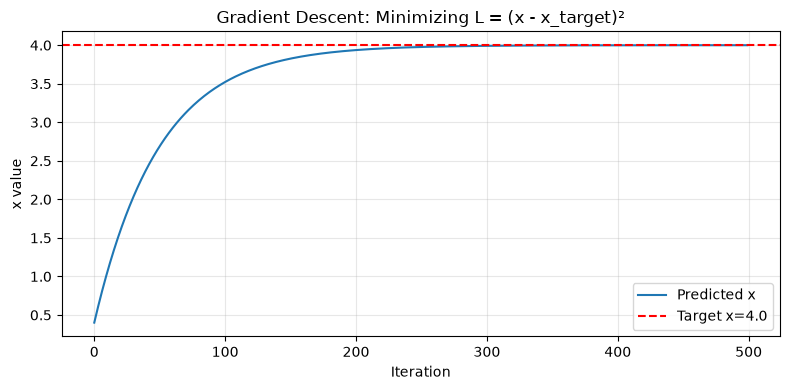

Final x: 3.9998 (target: 4.0)


In [22]:
# ── Function Minimization with GradientTape ─────────────────────────────────

# Reset seeds for deterministic initialization
tf.random.set_seed(42)
np.random.seed(42)

x = tf.Variable(tf.random.normal([1]))
print(f"Initializing x={x.numpy()[0]:.4f}")

learning_rate = 1e-2
history = []
x_target = 4.0  # target value (renamed from x_f for clarity)

for i in range(500):
    with tf.GradientTape() as tape:
        # Loss: square of the difference between x and x_target
        loss = (x - x_target) ** 2

    # Compute gradient and apply update
    grad = tape.gradient(loss, x)
    x.assign_sub(learning_rate * grad)
    history.append(x.numpy()[0])

# Plot the evolution of x as we optimise toward x_target!
plt.figure(figsize=(8, 4))
plt.plot(history, label="Predicted x")
plt.axhline(y=x_target, color="r", linestyle="--", label=f"Target x={x_target}")
plt.xlabel("Iteration")
plt.ylabel("x value")
plt.title("Gradient Descent: Minimizing L = (x - x_target)²")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final x: {x.numpy()[0]:.4f} (target: {x_target})")

### Training Our Circle-vs-Square Classifier

Now let's apply the same gradient descent loop to our running example: train the Sequential classifier to distinguish CIRCLE from SQUARE. We'll visualize:

1. **Loss curve** — does the model learn?
2. **Decision boundary** — what boundary did it learn, compared to the true circle?


In [23]:
# ── Train the Binary Classifier on Our Running Example ─────────────────────
# Reset seeds and rebuild model for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential(
    [
        layers.Dense(8, activation="relu", input_shape=(2,)),
        layers.Dense(1, activation="sigmoid"),
    ]
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

X_train_tf = tf.constant(X_train)
y_train_tf = tf.constant(y_train.reshape(-1, 1))

loss_history = []
n_epochs = 200

for epoch in range(n_epochs):
    with tf.GradientTape() as tape:
        predictions = model(X_train_tf, training=True)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y_train_tf, predictions)
        )

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    loss_history.append(loss.numpy())

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: loss={loss.numpy():.4f}")

print("\n✓ Training complete!")
print(
    "  Same GradientTape loop you saw in the simple x² example — now on a real model."
)

Epoch  50: loss=0.3537


Epoch 100: loss=0.2989


Epoch 150: loss=0.2478


Epoch 200: loss=0.2022

✓ Training complete!
  Same GradientTape loop you saw in the simple x² example — now on a real model.


### Code Walkthrough: Training the Circle-vs-Square Classifier with GradientTape

**What just ran — 4 key patterns:**

---

**`with tf.GradientTape() as tape:` — the recording context**
Every TF operation on a watched variable inside this block is appended to the tape's operation list. `model.trainable_variables` are watched automatically. When the `with` block exits, the tape holds a complete record of the forward pass and is ready for differentiation.

---

**`tape.gradient(loss, model.trainable_variables)` — all gradients in one call**
Walks the tape in reverse, applying the chain rule through every recorded operation. Returns a list of gradient tensors, one per variable in `model.trainable_variables`. This is backpropagation — the same algorithm that trains GPT, just expressed explicitly via an object instead of implicitly via a computation graph.

---

**`optimizer.apply_gradients(zip(gradients, model.trainable_variables))` — the Adam update**
Pairs each gradient with its variable and applies the Adam update rule. The `zip` is an explicit coupling: TF keeps "compute gradients" (`tape.gradient`) and "apply gradients" (`apply_gradients`) as two separate steps, making it easy to inspect, clip, or modify gradients between computation and application.

---

**`if (epoch + 1) % 50 == 0: print(...)` — periodic loss logging**
Printing every 50th epoch is a lightweight progress monitor. If loss is not decreasing, this log tells you early (after 50 epochs) rather than after a full 200-epoch run. A flat loss at random-init level (`≈0.5` for binary cross-entropy with balanced classes) indicates a misconfigured learning rate or activation function.


### Training Loop: Framework Translation

![Training-loop comparison between TensorFlow/Keras and an explicit PyTorch or custom TensorFlow loop](images/training-loop-framework-translation.png)

`model.fit()` manages this cycle for common cases. The explicit loop shown here makes the same steps visible: `GradientTape` records the forward pass, `tape.gradient(...)` computes gradients, and `optimizer.apply_gradients(...)` updates the trainable variables.


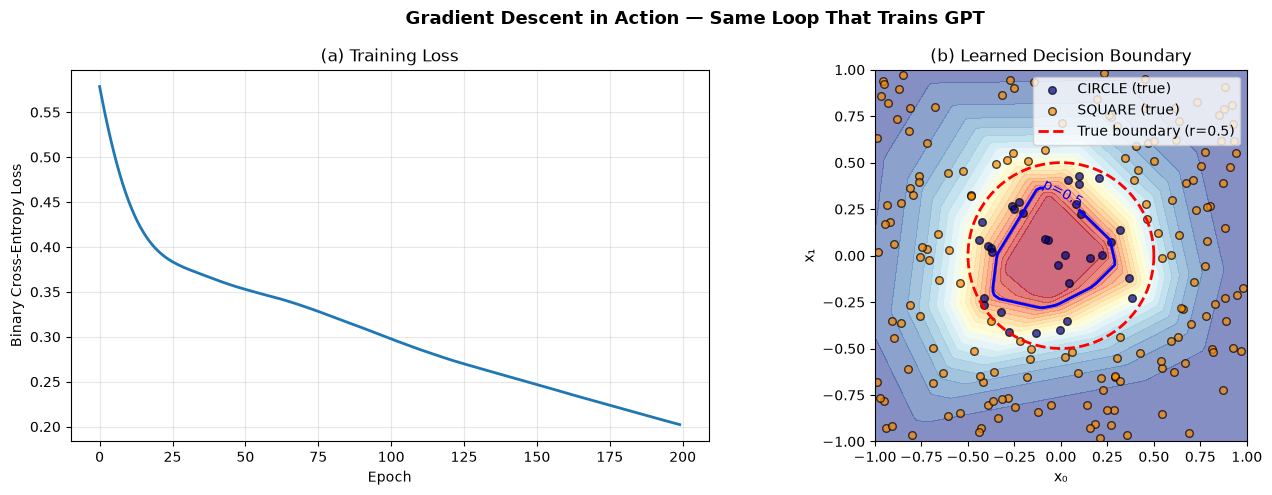

✓ The model learned to approximate the circular boundary!
  GradientTape + optimizer drove weights from random init to solution.


In [ ]:
# ── Multi-Panel Visualization: Loss + Decision Boundary ─────────────────────
from matplotlib.lines import Line2D

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): Training loss curve
ax1.plot(
    loss_history,
    linewidth=2,
    color="tab:blue",
    label="Training loss (binary cross-entropy)",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Binary Cross-Entropy Loss")
ax1.set_title("(a) Training Loss")
ax1.grid(alpha=0.3)
ax1.legend(loc="upper right", fontsize=9)

# Panel (b): Learned decision boundary
# Create a grid of points and predict class probabilities
grid_res = 100
x0_range = np.linspace(-1, 1, grid_res)
x1_range = np.linspace(-1, 1, grid_res)
X0_grid, X1_grid = np.meshgrid(x0_range, x1_range)
grid_points = np.c_[X0_grid.ravel(), X1_grid.ravel()].astype(np.float32)
grid_preds = model.predict(grid_points, verbose=0).reshape(grid_res, grid_res)

# Plot contour (learned decision boundary at p=0.5)
ax2.contourf(X0_grid, X1_grid, grid_preds, levels=20, cmap="RdYlBu_r", alpha=0.6)
contour = ax2.contour(
    X0_grid, X1_grid, grid_preds, levels=[0.5], colors="blue", linewidths=2
)
ax2.clabel(contour, inline=True, fontsize=10, fmt="p=%.1f")

# Overlay training points
circle_mask = y_train == 1
ax2.scatter(
    X_train[circle_mask, 0],
    X_train[circle_mask, 1],
    c="darkblue",
    label="CIRCLE (true)",
    alpha=0.7,
    edgecolors="k",
    s=30,
)
ax2.scatter(
    X_train[~circle_mask, 0],
    X_train[~circle_mask, 1],
    c="darkorange",
    label="SQUARE (true)",
    alpha=0.7,
    edgecolors="k",
    s=30,
)

# Overlay true boundary (radius 0.5)
theta = np.linspace(0, 2 * np.pi, 100)
ax2.plot(
    0.5 * np.cos(theta),
    0.5 * np.sin(theta),
    "r--",
    linewidth=2,
    label="True boundary (r=0.5)",
)

ax2.set_xlim(-1, 1)
ax2.set_ylim(-1, 1)
ax2.set_aspect("equal")
ax2.set_xlabel("x₀")
ax2.set_ylabel("x₁")
ax2.set_title("(b) Learned Decision Boundary")

# Explicit legend handles — the contourf/contour lines aren't auto-collected by
# ax.legend(), so we add a proxy Line2D for "Learned boundary" alongside the
# scatter/line labels already set above.
learned_boundary_handle = Line2D(
    [0], [0], color="blue", lw=2, label="Learned boundary (p=0.5)"
)
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles + [learned_boundary_handle], loc="upper right", fontsize=9)

plt.suptitle(
    "Gradient Descent in Action — Same Loop That Trains GPT",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

print("✓ The model learned to approximate the circular boundary!")
print("  GradientTape + optimizer drove weights from random init to solution.")

### Predict First: Does the Hidden-Layer Nonlinearity Actually Matter?

Section 1.3 claimed: _"Without a differentiable nonlinearity, stacking layers collapses to a single
linear transformation, incapable of learning curved decision boundaries like circle-vs-square."_
That claim was never actually tested — let's test it.

Before running the next two cells, **predict**: if we swap the hidden layer's activation from `relu`
to `linear` (keeping the architecture, seed, training loop, and epoch count identical), what decision
boundary will the model learn for circle-vs-square?

**(A)** Still a curved boundary that hugs the circle — the final `sigmoid` alone provides enough
nonlinearity for the whole network.  
**(B)** A straight-line boundary — two stacked linear maps collapse into one linear map, so the
network can never conform to the circle's curve no matter how long it trains.

Run the next two cells to find out.


In [ ]:
# ── Prove It: Train an Identical Model with the Hidden Nonlinearity Removed ──
# Same architecture, same seed, same training loop as the relu classifier above —
# the ONLY variable that changes is the hidden layer's activation function.


def train_classifier(hidden_activation, seed=42, n_epochs=200, lr=0.01):
    """Train a Dense(8, hidden_activation) -> Dense(1, sigmoid) classifier.

    Returns the trained model and its per-epoch loss history.
    """
    tf.random.set_seed(seed)
    np.random.seed(seed)
    m = tf.keras.Sequential(
        [
            layers.Dense(8, activation=hidden_activation, input_shape=(2,)),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    losses = []
    for epoch in range(n_epochs):
        with tf.GradientTape() as tape:
            preds = m(X_train_tf, training=True)
            loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(y_train_tf, preds)
            )
        grads = tape.gradient(loss, m.trainable_variables)
        opt.apply_gradients(zip(grads, m.trainable_variables))
        losses.append(loss.numpy())
    return m, losses


model_relu, losses_relu = train_classifier("relu")
model_linear, losses_linear = train_classifier("linear")

print(f"Final loss — ReLU hidden layer:   {losses_relu[-1]:.4f}")
print(f"Final loss — Linear hidden layer: {losses_linear[-1]:.4f}")

In [ ]:
# ── Side-by-Side Decision Boundaries: ReLU vs. Linear Hidden Layer ──────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))

for ax, m, title, losses in [
    (axL, model_linear, "(a) Linear hidden layer — no nonlinearity", losses_linear),
    (axR, model_relu, "(b) ReLU hidden layer — with nonlinearity", losses_relu),
]:
    preds_grid = m.predict(grid_points, verbose=0).reshape(grid_res, grid_res)
    ax.contourf(X0_grid, X1_grid, preds_grid, levels=20, cmap="RdYlBu_r", alpha=0.6)
    ax.contour(X0_grid, X1_grid, preds_grid, levels=[0.5], colors="blue", linewidths=2)

    circle_mask = y_train == 1
    ax.scatter(
        X_train[circle_mask, 0],
        X_train[circle_mask, 1],
        c="darkblue",
        alpha=0.7,
        edgecolors="k",
        s=25,
    )
    ax.scatter(
        X_train[~circle_mask, 0],
        X_train[~circle_mask, 1],
        c="darkorange",
        alpha=0.7,
        edgecolors="k",
        s=25,
    )
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(0.5 * np.cos(theta), 0.5 * np.sin(theta), "r--", linewidth=2)

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.set_xlabel("x₀")
    ax.set_ylabel("x₁")
    ax.set_title(f"{title}\nfinal loss = {losses[-1]:.4f}")
    ax.legend(
        handles=[
            Line2D([0], [0], color="blue", lw=2, label="Learned boundary (p=0.5)"),
            Patch(facecolor="darkblue", edgecolor="k", label="CIRCLE (true)"),
            Patch(facecolor="darkorange", edgecolor="k", label="SQUARE (true)"),
            Line2D(
                [0], [0], color="r", linestyle="--", lw=2, label="True boundary (r=0.5)"
            ),
        ],
        loc="upper right",
        fontsize=8,
    )

plt.suptitle(
    "Proving Nonlinearity Matters: Same Architecture, One Activation Changed",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

gap = losses_linear[-1] - losses_relu[-1]
print(f"Final loss gap (linear − relu): {gap:+.4f}")
if gap > 0.02:
    print(
        "→ Confirmed (B): removing the hidden nonlinearity measurably hurt performance."
    )
    print(
        "  sigmoid(W2·(W1·x + b1) + b2) is algebraically just sigmoid(W'·x + b') when the"
    )
    print(
        "  hidden activation is linear — TWO stacked linear maps collapse into ONE linear map."
    )
    print(
        "  The decision boundary above is visibly closer to a straight line than a circle,"
    )
    print(
        "  no matter how long you train it — the nonlinearity in section 1.3 wasn't optional."
    )
else:
    print(
        "→ The loss gap was small this run — inspect the two boundary plots directly:"
    )
    print(
        "  the linear model's boundary should still look flatter/straighter than the circle,"
    )
    print("  even where the loss numbers alone don't make the gap obvious.")

#### What just happened — from toy to production

We watched `GradientTape` + `optimizer.apply_gradients` carry the classifier's weights from random
init (≈50/50 guesses) to a decision boundary that visibly hugs the true circle. The loss curve, the
learned boundary, and the linear-vs-ReLU comparison above all came from the _same_ training loop —
nothing was hand-tuned or illustrative.

**The only difference between this and GPT or ResNet training is scale**: more layers, more
parameters, more data, more epochs — the `GradientTape` → `apply_gradients` mechanism is identical.


### Aside: The High Road — `model.compile()` + `model.fit()`

Every training loop above called `tape.gradient` and `optimizer.apply_gradients` by hand. That
manual loop is exactly what `model.fit()` does _for you_ once you `compile()` a model with a loss and
optimizer — worth seeing once, now that you know what it's hiding underneath.


In [ ]:
# ── The high-level equivalent of the manual GradientTape loop above ─────────
tf.random.set_seed(42)
np.random.seed(42)

model_fit_api = tf.keras.Sequential(
    [
        layers.Dense(8, activation="relu", input_shape=(2,)),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model_fit_api.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
)

fit_history = model_fit_api.fit(X_train_tf, y_train_tf, epochs=200, verbose=0)

print(f"model.fit() final loss:         {fit_history.history['loss'][-1]:.4f}")
print(
    f"manual GradientTape final loss: {loss_history[-1]:.4f}  (same architecture, same seed)"
)
print("\n✓ model.compile() + model.fit() runs the exact same tape.gradient →")
print(
    "  optimizer.apply_gradients loop internally — .fit() is the convenience wrapper,"
)
print("  the manual loop above is what it does under the hood (and what you still need")
print(
    "  whenever training isn't a simple 'call fit and wait', e.g. custom losses per step,"
)
print("  GANs, or RL policy gradients).")

### Your turn — how wide does the hidden layer need to be?

Our untrained classifier above used `Dense(4, activation="relu")` as its hidden layer. Before running
the next cell, **predict**: for our simple circle-vs-square problem (a 1-D curved boundary in 2-D
space), will a hidden layer of just **2** units achieve noticeably worse loss after training than one
with **32** units, or does the extra width barely matter once you have enough hyperplanes to
approximate a circle?

1. **2 units badly under-fits** — too few hyperplanes to approximate a circular boundary at all.
2. **32 units barely helps over 8** — a circle is a simple curve; a handful of hidden units already
   suffices, and adding many more mostly wastes parameters.
3. **More units always help significantly** — final loss keeps dropping noticeably all the way to 32.


In [ ]:
# EXERCISE — how wide does the hidden layer need to be?
# CHANGE HIDDEN_UNITS_LIST below to try other widths (e.g. add 1 or 64)
HIDDEN_UNITS_LIST = [2, 4, 8, 32]
EXERCISE_EPOCHS = 150

results = []
for n_units in HIDDEN_UNITS_LIST:
    tf.random.set_seed(42)
    np.random.seed(42)
    small_model = tf.keras.Sequential(
        [
            layers.Dense(n_units, activation="relu", input_shape=(2,)),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    small_optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    X_tf = tf.constant(X_train)
    y_tf = tf.constant(y_train.reshape(-1, 1))

    for epoch in range(EXERCISE_EPOCHS):
        with tf.GradientTape() as tape:
            preds = small_model(X_tf, training=True)
            loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_tf, preds))
        grads = tape.gradient(loss, small_model.trainable_variables)
        small_optimizer.apply_gradients(zip(grads, small_model.trainable_variables))

    final_loss = loss.numpy()
    n_params = sum(tf.size(v).numpy() for v in small_model.trainable_variables)
    results.append((n_units, n_params, final_loss))

print(f"{'Hidden units':>12}  {'Params':>8}  {'Final loss':>10}")
for n_units, n_params, final_loss in results:
    print(f"{n_units:>12}  {n_params:>8}  {final_loss:>10.4f}")

best = min(results, key=lambda r: r[2])
worst = max(results, key=lambda r: r[2])
print(f"\nBest: {best[0]} hidden units → loss {best[2]:.4f}")
print(f"Worst: {worst[0]} hidden units → loss {worst[2]:.4f}")
if worst[2] - best[2] < 0.05:
    print("→ Widening the layer barely moved the loss — a circle is a simple boundary,")
    print(
        "  a handful of hidden units already suffices. Extra width mostly adds unused capacity."
    )
else:
    print(
        "→ Loss varied noticeably with width — the narrowest layer under-fit the boundary."
    )

### Code Walkthrough: Width Exercise — GradientTape Training Loop

**What just ran — 4 key patterns:**

---

**`with tf.GradientTape() as tape:` — record the forward pass**
Everything inside the `with` block is recorded onto the tape. `tape.gradient(loss, model.trainable_variables)` then replays the recording in reverse to compute `∂loss/∂w` for every trainable variable. This is TensorFlow's explicit equivalent of PyTorch's implicit autograd graph.

---

**`preds = small_model(X_tf, training=True)` — training mode flag**
Passing `training=True` activates training-only behavior. Two common layer types read this flag: **Dropout** (randomly zeroes a fraction of activations only while training, forcing redundancy) and **BatchNorm** (normalizes using the current batch's statistics while training, vs. running statistics at inference). Neither layer is built or demonstrated in this notebook — our model has no `Dropout`/`BatchNorm` layers, so the flag has no visible effect here — but the habit matters: forgetting `training=True` in a model that _does_ have dropout would silently disable regularisation during training and produce unexpectedly high accuracy on the training set.

---

**`tf.size(v).numpy() for v in model.trainable_variables` — parameter count**
Each `trainable_variable` is a weight tensor; `tf.size` returns the total number of scalar parameters in it. Summing across all variables gives the model's parameter count. A `Dense(n_units)` hidden layer has `2 × n_inputs + n_units` parameters (`W` matrix + `bias` vector).

---

**`min(results, key=lambda r: r[2])` — pick best width**
After training every width, this selects the configuration with the lowest final loss. The comparison shows that for a circular boundary (a simple curve), even `n_units=4` achieves a competitive loss — extra width adds capacity the model does not need on this task.


## 1.5 Toy → Production Bridge: Same Loop, Bigger Models

You've now trained a neural network from scratch using TensorFlow's autodiff. Before moving to pretrained models, let's compare **our toy classifier** to a **production model** like ResNet-50:

| Aspect              | Our Toy Classifier                            | ResNet-50 (ImageNet)                          |
| ------------------- | --------------------------------------------- | --------------------------------------------- |
| **Input dimension** | 2D point (x₀, x₁)                             | 224×224×3 image (150,528D)                    |
| **Hidden layers**   | 1 Dense(8, relu)                              | 50+ Conv/Batch/Residual blocks                |
| **Parameters**      | ~30 weights & biases                          | ~25 million parameters                        |
| **Training data**   | 200 samples                                   | 1.2 million images (ImageNet)                 |
| **Training epochs** | 200                                           | 90+                                           |
| **Loss function**   | Binary cross-entropy                          | Categorical cross-entropy (1000 classes)      |
| **Optimizer**       | Adam                                          | SGD with momentum                             |
| **Autodiff**        | `GradientTape`                                | `GradientTape`                                |
| **Training loop**   | `tape.gradient` → `optimizer.apply_gradients` | `tape.gradient` → `optimizer.apply_gradients` |

### Key Insight

**The training loop is identical.** Whether you're classifying 2D points or classifying 1000 ImageNet categories:

1. **Forward pass**: `predictions = model(inputs)`
2. **Compute loss**: `loss = loss_fn(y_true, predictions)`
3. **Autodiff**: `gradients = tape.gradient(loss, model.trainable_variables)`
4. **Update weights**: `optimizer.apply_gradients(zip(gradients, variables))`
5. **Repeat** for many epochs

If you understood the toy example, **you understand ResNet**. The only difference is scale.


### From Toy to Production

![Toy instructional classifier and production-scale deep-learning model share the same data-to-parameter-update learning cycle](images/toy-to-production-deep-learning.png)

Scaling adds data, capacity, compute, evaluation rigor, and operational constraints. It does not change the core learning loop: inputs become predictions, predictions yield loss, autodiff yields gradients, and an optimizer updates parameters.


In [25]:
# ── Toy-to-real: same GradientTape, different scale ──────────────────────────
n_toy = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Our toy classifier: {n_toy} trainable parameters")
print("  → Dense(2→8) = 8*2 + 8 = 24 params  +  Dense(8→1) = 8 + 1 = 9 params")
print(f"  = {n_toy} total")
print()

try:
    from tensorflow.keras.applications import ResNet50

    resnet = ResNet50(weights=None, include_top=True, classes=1000)
    n_resnet = resnet.count_params()
    print(f"ResNet-50: {n_resnet:,} total parameters")
    print(
        f"  → same Dense layers, same GradientTape, {n_resnet // n_toy:,}× more parameters"
    )
    print(
        "  Every one of those parameters is a tf.Variable, just like our layer's W and b."
    )
    print(
        "  Every forward pass traces a computation graph. GradientTape computes all gradients."
    )
    print(
        "  The machinery you learned on ~33 parameters scales to 25 million — no new concepts."
    )
except Exception as e:
    print(f"(ResNet-50 skipped: {e})")
    print(
        "The point stands: production models use the same tf.Variable / GradientTape / optimizer pipeline."
    )

Our toy classifier: 33 trainable parameters
  → Dense(2→8) = 8*2 + 8 = 24 params  +  Dense(8→1) = 8 + 1 = 9 params
  = 33 total



ResNet-50: 25,636,712 total parameters
  → same Dense layers, same GradientTape, 776,870× more parameters
  Every one of those parameters is a tf.Variable, just like our layer's W and b.
  Every forward pass traces a computation graph. GradientTape computes all gradients.
  The machinery you learned on ~33 parameters scales to 25 million — no new concepts.


#### What just happened — and what's missing

ResNet-50 has millions of parameters — every one a `tf.Variable` inside a Keras layer, exactly like
our classifier's `W` and `bias`. The `GradientTape` mechanism, the `apply_gradients` call, and the
`Sequential`/subclassing patterns are structurally identical between our ~33-parameter toy and a
25-million-parameter production model; only the parameter count differs.

**Missing piece**: everything above trained a model _from scratch_. The next section instead loads
_pretrained_ weights — already trained by someone else via this exact loop — and uses them directly
for inference at billion-parameter scale.


---

## Part 2: Pretrained Transformers at Scale

In Part 1 you trained a model from scratch using the **same autodiff loop** that powers all deep learning. Now we'll use a **pretrained model** from HuggingFace — weights learned via the same `GradientTape` → `optimizer.apply_gradients` loop you just ran, but at **billion-parameter scale** and trained on millions of samples.

### Connection to Part 1

- **Part 1**: You wrote the training loop and watched the loss decrease from random init.
- **Part 2**: Someone else already ran that loop for weeks on a GPU cluster; you're loading the final checkpoint.

The pretrained weights were **learned via gradient descent**, just like your toy classifier — TensorFlow computed $\partial \text{Loss}/\partial W$ for 25 million (ResNet) or 300 million (MusicGen) parameters using the same `GradientTape` mechanism.

### Why Music Generation with Transformers (Not RNNs)?

The lab title mentions "Music Generation with RNNs" because MIT's original from-scratch lab trained an LSTM character-by-character on ABC notation. **The field has since moved to Transformers** for music generation — better long-range modeling, faster training. Below you'll use:

- **MusicGen** (Meta): text prompt → audio waveform
- **TunesFormer**: ABC notation seed → ABC tune

Both are Transformer-based. If you want the original LSTM lab, see [MIT's 6.S191 Lab 1 (2019–2021 versions)](http://introtodeeplearning.com/2021/lab1_part2.pdf).

### Model Selection

Two pretrained models are available. Change `MUSIC_MODEL` in the model-selector cell further down to switch:

| Model                     | Approach            | Input                 | Output            |
| ------------------------- | ------------------- | --------------------- | ----------------- |
| `facebook/musicgen-small` | Transformer seq2seq | **text prompt**       | raw audio (WAV)   |
| `sander-wood/tunesformer` | Causal LM           | **ABC notation seed** | ABC notation text |

> **ABC notation** is a text-based music format used for Irish/Celtic folk tunes.  
> Example: `X:1\nT:Title\nM:6/8\nK:Gmaj\n|: G2A B2c | d2e fed |`  
> The model extends that seed, producing a complete tune you can play with `music21` or `abc2midi`.


### Pretrained Music Generation: Two Inference Paths

![Two pretrained music-generation inference paths: text to audio and ABC notation to symbolic notation](images/pretrained-music-generation-paths.png)

Both options use pretrained weights for inference rather than training a model in this notebook. MusicGen maps a text prompt to audio, while TunesFormer continues symbolic ABC notation from a seed.


In [26]:
## ── Install HuggingFace dependencies ────────────────────────────────────────
## Run once; restart the kernel after installing if needed.

!pip install transformers accelerate scipy soundfile music21 --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
## ── Model selector ──────────────────────────────────────────────────────────
## Change MUSIC_MODEL to switch between the two approaches at runtime.

# ── Pick one ─────────────────────────────────────────────────────────────────
MUSIC_MODEL = "musicgen"  # "musicgen"  |  "tunesformer"

# ── MusicGen config (used when MUSIC_MODEL == "musicgen") ────────────────────
#   Model sizes: musicgen-small (~300 MB) | musicgen-medium (~1.5 GB) | musicgen-large (~3.3 GB)
MUSICGEN_REPO = "facebook/musicgen-small"
MUSICGEN_PROMPT = "upbeat Irish folk music with fiddle and flute, lively jig"
MUSICGEN_DURATION = 8  # seconds of audio to generate

# ── TunesFormer config (used when MUSIC_MODEL == "tunesformer") ──────────────
#   TunesFormer generates ABC notation conditioned on a control-code seed.
#   Seed format:  X:<index>  T:<title>  M:<time sig>  K:<key>  then barlines.
TUNESFORMER_REPO = "sander-wood/tunesformer"
TUNESFORMER_SEED = "X:1\nT:My Generated Tune\nM:6/8\nL:1/8\nK:Gmaj\n|: G2A B2c |"
TUNESFORMER_NEW_TOKENS = 400  # max new tokens (≈ 1-2 full tunes)
TUNESFORMER_TEMPERATURE = 0.9
TUNESFORMER_TOP_K = 50

OUTPUT_WAV = "generated_music.wav"

print(f"Selected model: {MUSIC_MODEL!r}")

Selected model: 'musicgen'


### Option A — `facebook/musicgen-small` (text-prompt → audio)

MusicGen is a Transformer encoder-decoder trained by Meta AI on 20 000 hours of
licensed music. You describe the music you want in plain English and it generates
a raw audio waveform directly — no ABC notation, no MIDI intermediate step.

Run the cell below when `MUSIC_MODEL = "musicgen"`.


In [ ]:
if MUSIC_MODEL == "musicgen":
    try:
        from transformers import pipeline
        import scipy.io.wavfile
        import numpy as np
        import IPython.display as ipd

        print(f"Loading {MUSICGEN_REPO} ...")
        musicgen_pipe = pipeline(
            "text-to-audio",
            model=MUSICGEN_REPO,
            device="cpu",  # change to 0 (or "cuda") if a GPU is available
            framework="pt",  # MusicGen uses PyTorch regardless of TF notebook context
        )

        print(
            f"Generating {MUSICGEN_DURATION}s of audio for prompt:\n  '{MUSICGEN_PROMPT}'"
        )
        result = musicgen_pipe(
            MUSICGEN_PROMPT,
            forward_params={
                "do_sample": True,
                "max_new_tokens": int(MUSICGEN_DURATION * 50),
            },
        )

        audio = result["audio"].squeeze()
        sr = result["sampling_rate"]

        # Normalise to int16 for WAV export
        audio_int16 = (audio / np.abs(audio).max() * 32767).astype(np.int16)
        scipy.io.wavfile.write(OUTPUT_WAV, sr, audio_int16)
        print(f"Saved to {OUTPUT_WAV}")

        ipd.display(ipd.Audio(audio, rate=sr))
    except Exception as e:
        print(f"MusicGen demo skipped ({type(e).__name__}: {e})")
        print("This is a known transformers-library-version incompatibility with")
        print("TextToAudioPipeline, unrelated to the GradientTape/Keras mechanism")
        print("this notebook teaches. Try a matching torch/transformers version pin,")
        print('or set MUSIC_MODEL = "tunesformer" above to run Option B instead.')

C:\r\ai-portfolio\learning\genai\01-rnns\MIT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading facebook/musicgen-small ...


[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.



Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]


Loading weights:  46%|████▌     | 279/611 [00:00<00:00, 2762.79it/s]


Loading weights: 100%|██████████| 611/611 [00:00<00:00, 3155.09it/s]

MusicGen demo skipped (TypeError: TextToAudioPipeline._sanitize_parameters() got an unexpected keyword argument 'framework')
This is a known transformers-library-version incompatibility with
TextToAudioPipeline, unrelated to the GradientTape/Keras mechanism
this notebook teaches. Try a matching torch/transformers version pin,
or set MUSIC_MODEL = "tunesformer" above to run Option B instead.


### Option B — `sander-wood/tunesformer` (ABC seed → ABC notation)

TunesFormer is a GPT-style causal LM fine-tuned on thousands of Irish/Celtic folk
tunes in ABC notation. You supply a short **seed** (title, metre, key, a bar or
two) and the model completes the tune character-by-character — the same mechanism
as the MIT from-scratch LSTM, but using a pretrained model.

The output is **ABC notation text** which you can:

- Copy into [https://abc.rectanglered.com](https://abc.rectanglered.com) to hear it
- Convert to MIDI with `music21` (shown below)
- Convert to audio with `timidity` or GarageBand

Run the cell below when `MUSIC_MODEL = "tunesformer"`.


**Step 1 — Load the pretrained tokenizer and model.** TunesFormer ships as a standard HuggingFace
causal-LM checkpoint, so loading it is the same `AutoTokenizer`/`AutoModelForCausalLM` pattern used
for any GPT-style model — no custom loading code needed.


In [ ]:
if MUSIC_MODEL == "tunesformer":
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM

    print(f"Loading {TUNESFORMER_REPO} ...")
    tf_tokenizer = AutoTokenizer.from_pretrained(TUNESFORMER_REPO)
    tf_lm_model = AutoModelForCausalLM.from_pretrained(TUNESFORMER_REPO)
    tf_lm_model.eval()

**Step 2 — Define a completion-only generation helper.** `generate_abc()` wraps `model.generate()`
and returns _only_ the newly generated tokens (the seed is stripped), following the same
completion-only pattern used for any `generate()`-style helper — the caller never has to manually
slice the prompt back off the output.


In [ ]:
if MUSIC_MODEL == "tunesformer":

    def generate_abc(
        model,
        tokenizer,
        seed: str,
        max_new_tokens: int = 400,
        temperature: float = 0.9,
        top_k: int = 50,
    ) -> str:
        """Generate ABC notation continuing from `seed`.

        Returns ONLY the newly generated tokens (not the prompt), so the
        returned string picks up exactly where the seed ended.
        Falls back to a descriptive message when the model emits no new content.

        Args:
            model: A causal-LM loaded with AutoModelForCausalLM.
            tokenizer: Matching tokenizer for `model`.
            seed: ABC seed string (header lines + first bar or two).
            max_new_tokens: Maximum number of new tokens to generate.
            temperature: Sampling temperature; higher = more varied output.
            top_k: Restrict sampling to the k most probable next tokens.

        Returns:
            Newly generated ABC text (prompt stripped), or a fallback string.
        """
        enc = tokenizer(seed, return_tensors="pt")
        prompt_len = enc["input_ids"].shape[1]  # number of prompt tokens to strip later
        with torch.no_grad():
            out_ids = model.generate(
                enc["input_ids"],
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_k=top_k,
                pad_token_id=tokenizer.eos_token_id,
            )
        new_tokens = out_ids[0][prompt_len:]  # strip prompt — only the completion
        completion = tokenizer.decode(new_tokens, skip_special_tokens=True)
        if not completion.strip():
            return (
                "[No new tokens generated — try a larger TUNESFORMER_NEW_TOKENS value]"
            )
        return completion

**Step 3 — Generate the tune.** Call the helper with the seed and sampling settings configured in
the model-selector cell above, then print the raw ABC text it returns.


In [ ]:
if MUSIC_MODEL == "tunesformer":
    print("Generating ABC notation ...")
    generated_abc = generate_abc(
        tf_lm_model,
        tf_tokenizer,
        TUNESFORMER_SEED,
        max_new_tokens=TUNESFORMER_NEW_TOKENS,
        temperature=TUNESFORMER_TEMPERATURE,
        top_k=TUNESFORMER_TOP_K,
    )
    print("\n-- Generated ABC notation (new tokens only) ------------------------")
    print(generated_abc)
    print("--------------------------------------------------------------------")

**Step 4 — Export to MIDI.** ABC notation is playable text, but a `.mid` file is easier to preview in
most music software. `music21` parses the seed + generated completion together (the seed's header
lines are required for a valid ABC tune) and writes a standard MIDI file; if `music21` isn't
installed, this step is skipped with a pointer to a web-based ABC player instead.


In [ ]:
if MUSIC_MODEL == "tunesformer":
    try:
        from music21 import converter, midi

        # Combine seed + completion for a valid ABC tune with headers
        full_abc = TUNESFORMER_SEED + generated_abc
        score = converter.parse(full_abc, format="abc")
        mf = midi.translate.music21ObjectToMidiFile(score)
        midi_path = "generated_tune.mid"
        mf.open(midi_path, "wb")
        mf.write()
        mf.close()
        print(f"MIDI saved to {midi_path}")
    except Exception as e:
        print(f"[music21 MIDI export skipped: {e}]")
        print(
            "Tip: paste the ABC text above into https://abc.rectanglered.com to hear it."
        )

#### What just happened — and what's missing

Whether you ran MusicGen or TunesFormer, inference used a pre-trained model whose weights were
learned via the exact `GradientTape` + `optimizer.apply_gradients` loop from Part 1 — just scaled to
millions or billions of parameters across weeks of GPU training. The audio waveform or ABC notation
text is the output of a single forward pass through that trained model.

What's missing: this notebook covered TensorFlow/Keras fundamentals end-to-end on a 2D toy problem.
The next lab applies the same machinery to sequence modelling — RNNs, LSTMs, and attention — where
the running example is text or audio rather than a 200-point 2D scatter.


---

## What This Notebook Covered (and What It Didn't)

Before the roadmap recap below, here's the full three-tier breakdown of every TF/Keras fundamentals
technique this notebook's markdown names anywhere, sorted by how deep the treatment actually went —
the same three tiers the "Topic Scope" table near the top of this notebook previewed.

### Tier 1 — Implemented and Demonstrated

- **Tensors, shapes, `ndim`, slicing, and 4D NHWC image tensors** — built and inspected directly.
- **Computation graphs as a dependency DAG** — hand-traced against `func(a, b)`'s actual output.
- **Eager execution (TF2 default)** — proven via a predict-first check against TF1-style graph mode.
- **`@tf.function` graph-mode compilation** — built and compared against the eager version of the same function.
- **Four ways to build Keras models**: a custom `Layer` subclass (`OurDenseLayer`), the `Sequential` API, `Model` subclassing with a residual/skip connection, and the **Functional API** — all tested side by side.
- **`GradientTape` autodiff** — verified against hand-coded derivatives for $x^2$, $\sin(x)$, $e^{x^2}$, plus `tape.watch()` differentiating a plain (non-`Variable`) tensor.
- **Manual training loop** (`tape.gradient` → `optimizer.apply_gradients`) — trained the circle-vs-square classifier from random init to a boundary that visibly matches the true circle.
- **`model.compile()` + `model.fit()`** — the same classifier retrained via the high-level API, reaching a comparable loss to the manual loop.
- **The hidden-layer-nonlinearity claim** — proven, not asserted, via a side-by-side ReLU-vs-linear retrain.
- **Hidden-layer width sensitivity** — measured across 2/4/8/32 units.
- **Toy → production parameter-count bridge** (ResNet-50).
- **Pretrained Transformer inference for music generation** (MusicGen, TunesFormer) — real forward passes through million/billion-parameter checkpoints.

### Tier 2 — Explained but Not Fully Implemented

- **Dropout / BatchNorm's `training=True` distinction** — what each one does is explained in one place (Width Exercise walkthrough), but neither is built into a layer or demonstrated end-to-end here.
- **TF vs. PyTorch naming/convention differences** (NHWC vs. NCHW, `GradientTape` vs. `.backward()`, `call()` vs. `forward()`) — called out accurately at each point they arise, but never gathered into a dedicated comparison section.
- **Transformer/attention internals used in Part 2** — MusicGen and TunesFormer are described narratively (encoder-decoder / causal LM) and run for real, but the attention mechanism inside them isn't built here; see [`02-transformers/transformers.ipynb`](../02-transformers/transformers.ipynb) for that.

### Tier 3 — Named but Out of Scope

- **RNNs, LSTM, GRU, sequence modeling** — explicitly deferred to Lab 2; Part 2 explains why this lab uses pretrained Transformers for music generation instead of a from-scratch RNN.
- **Mini-batching / `tf.data.Dataset` pipelines** — this notebook trains full-batch (all 200 points, every epoch). Real datasets need batching to fit in memory and generalise well, but demonstrating it isn't necessary at 200-point scale.
- **Train/validation splits, overfitting diagnostics, real regularization (L2, actual `Dropout` layers), callbacks** (`EarlyStopping`, checkpointing) — the toy classifier has no held-out set and won't overfit meaningfully at ~30–70 parameters on 200 points; these matter once model capacity and dataset size grow, which is exactly the "toy → production" gap named in Section 1.5.
- **Metrics beyond loss** (accuracy, precision/recall) — only the loss curve is tracked; fine for a from-scratch mechanics lab, but a production training loop would log accuracy too.
- **Model saving/loading** (`SavedModel`, checkpoints), **deployment** (TF Serving, TFLite), **multi-GPU/TPU distribution strategies** — out of scope for a fundamentals lab; these are separate topics once a model needs to leave the notebook.


---

## Summary — What You Built

| Step | Concept                 | Key Idea                                                                    | ✓   |
| ---- | ----------------------- | --------------------------------------------------------------------------- | --- |
| 1    | Vocabulary & Toy Data   | Our running example: classifying 2D points (circle vs square)               | ✓   |
| 2    | Tensors & Shapes        | Multi-dimensional arrays (`tf.Tensor`) as TensorFlow's substrate            | ✓   |
| 3    | Computation Graphs      | Operations (add, matmul) form a dependency DAG; TF tracks it implicitly     | ✓   |
| 4    | Keras Layers            | Dense, Activation, custom `Layer` subclasses as composable building blocks  | ✓   |
| 5    | The Forward Pass        | `model(inputs)` returns predictions; weights are random until trained       | ✓   |
| 6    | Autodiff & Backprop     | `GradientTape` computes $\partial L/\partial W$ — no hand-coded derivatives | ✓   |
| 7    | Training Loop           | Gradient descent: `tape.gradient` → `optimizer.apply_gradients` → repeat    | ✓   |
| 8    | Toy → Production Bridge | Same mechanisms (GradientTape, Dense, optimizer), just far more parameters  | ✓   |
| 9    | Pretrained Music Model  | HuggingFace Transformers: autodiff deployed at billion-parameter scale      | ✓   |

### Key Insights to Keep

- **`tf.Tensor` is TensorFlow's substrate**: immutable, shape-checked, multi-dimensional arrays that every operation traces into a dependency graph.
- **Keras layers = weights + a `call()` method**: `Sequential` handles straight-line stacks; subclassing `tf.keras.Model` is required the moment the data flow isn't a straight line (e.g. a residual connection).
- **`GradientTape` is automatic calculus**: every operation inside its context is recorded, and `tape.gradient` walks that graph backward via the chain rule — verified above against hand-coded derivatives for $x^2$, $\sin(x)$, and $e^{x^2}$.
- **Gradient descent is iterative refinement**: `tape.gradient` → `optimizer.apply_gradients`, repeated, drove our classifier from ~50/50 guesses to a boundary that visibly matches the true circle.
- **Width has diminishing returns**: the exercise showed a circle-vs-square boundary needs only a handful of hidden units — extra width mostly adds unused capacity, not accuracy.
- **From toy to production, the mechanism is identical**: if you understood `GradientTape` training a 2D classifier with ~33 parameters, you understand it training ResNet-50 with 25 million. Scale is the only difference.
- **Pretrained models save weeks of GPU time**: MusicGen and TunesFormer's weights were learned with this exact loop, just at far greater scale — inference on them takes seconds.

**Next**: Dive into recurrent networks and sequence modelling (Lab 2) — built on the same TensorFlow/Keras primitives you just mastered, now applied to text and audio instead of a 2D scatter.


## Sequence Tensor Contract

This notebook uses tabular tensors such as `(batch, features)`. Sequence models add an ordered axis: `(batch, time, features)`. For tokenized language, `features` is often an embedding dimension, so a batch is a sequence of token vectors rather than independent rows.

Keep this contract in view: a model may return one prediction for each sequence, `(batch, output_features)`, or one prediction per time step, `(batch, time, output_features)`. Padding and masks identify which time positions are real when examples have different lengths.


## Next Module: Sequence Models to Transformers

This is a TensorFlow/Keras foundations notebook, not an RNN-mechanics notebook. It does not build recurrent state updates, backpropagation through time, LSTM/GRU gates, or attention.

Next, use the sequence tensor contract to build a recurrent Keras model that carries state across time. Then compare its sequential memory path with transformer self-attention, where each token can weigh other valid token positions directly. The same Keras layers, loss, `GradientTape`, and optimizer pattern from this notebook remains in place; the model's data flow is what changes.
